In [1]:
# Using https://github.com/DeepLearnPhysics/spine-workshop-2026/blob/main/basics/larcv/LArCV_visualization.ipynb for reference to look at LARCV files. 
import larcv
import ROOT

fname = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/electron_NDLAr_10MeVto15GeV_TEST5.1002.LARCV.root' # Change this path if you are not on NERSC
#fname = 'LOCAL_PATH'
f = ROOT.TFile(fname)
f.ls()

Welcome to JupyROOT 6.26/16
TFile**		/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/electron_NDLAr_10MeVto15GeV_TEST5.1002.LARCV.root	
 TFile*		/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/electron_NDLAr_10MeVto15GeV_TEST5.1002.LARCV.root	
  KEY: TTree	particle_pcluster_tree;2	pcluster tree [current cycle]
  KEY: TTree	particle_pcluster_tree;1	pcluster tree [backup cycle]
  KEY: TTree	sparse3d_pcluster_tree;1	pcluster tree
  KEY: TTree	sparse3d_pcluster_semantics_tree;1	pcluster_semantics tree
  KEY: TTree	cluster3d_pcluster_tree;1	pcluster tree
  KEY: TTree	cluster3d_pcluster_dedx_tree;1	pcluster_dedx tree


In [2]:
import uproot

tree = uproot.open(fname)
tree.keys()

['particle_pcluster_tree;2',
 'particle_pcluster_tree;1',
 'sparse3d_pcluster_tree;1',
 'sparse3d_pcluster_semantics_tree;1',
 'cluster3d_pcluster_tree;1',
 'cluster3d_pcluster_dedx_tree;1']

In [3]:
import numpy as np
tree = f.Get("cluster3d_pcluster_tree")
print('Number of entries', tree.GetEntries())

for entry in range(tree.GetEntries()):
    tree.GetEntry(entry)
    event = tree.cluster3d_pcluster_branch
    clusters = event.as_vector()
    print("Number of clusters = ", len(clusters))
    cluster_sizes = []
    for c in clusters:
        cluster_sizes.append(c.as_vector().size())
    print(np.sum(np.array(cluster_sizes)))

Number of entries 50
Number of clusters =  3299
6738
Number of clusters =  10694
22414
Number of clusters =  5709
11608
Number of clusters =  13650
28308
Number of clusters =  5641
11766
Number of clusters =  13221
27792
Number of clusters =  12808
27280
Number of clusters =  6267
13133
Number of clusters =  6125
12896
Number of clusters =  5637
11290
Number of clusters =  1242
2589
Number of clusters =  14645
31127
Number of clusters =  14916
31475
Number of clusters =  12962
27260
Number of clusters =  9191
18898
Number of clusters =  9812
20617
Number of clusters =  5380
11280
Number of clusters =  2679
5416
Number of clusters =  9498
19510
Number of clusters =  9145
19467
Number of clusters =  4530
9393
Number of clusters =  5899
12101
Number of clusters =  7312
15101
Number of clusters =  11339
23648
Number of clusters =  10103
20837
Number of clusters =  8371
17456
Number of clusters =  2989
6037
Number of clusters =  6914
14691
Number of clusters =  8650
17879
Number of clusters

In [4]:
tree = f.Get("particle_pcluster_tree")
print('Number of entries', tree.GetEntries())
energy_init_values = []
start_x = []
start_y = []
start_z = []

for entry in range(tree.GetEntries()):
    tree.GetEntry(entry)
    event = tree.particle_pcluster_branch
    #print("Event:", event)
    particles = event.as_vector()
    #print("Number of particles = ", len(particles))
    energy_init_values.append(particles[0].energy_init())
    start_x.append(particles[0].x())
    start_y.append(particles[0].y())
    start_z.append(particles[0].z())

print("Energy init values:", energy_init_values)
print("Start x:", start_x)
print("Start y:", start_y)
print("Start z:", start_z)
energy_init_values = np.array(energy_init_values)
start_x = np.array(start_x)
start_y = np.array(start_y)
start_z = np.array(start_z)
    

Number of entries 50
Energy init values: [2974.113966740333, 9821.457583780135, 5118.002268806913, 13097.451980488917, 5115.554883835658, 12529.871299136812, 12373.213482575593, 5774.057433322538, 5534.604225676233, 4835.661847638077, 1107.3664340896853, 13839.62498588598, 13851.216290432405, 11925.486578263362, 8298.230060864693, 9203.660407323847, 4878.143390620517, 2285.109634383977, 8566.301825854287, 8767.317255036087, 4142.712212811091, 5349.68750237749, 6500.151691227451, 10399.428114338409, 9114.361559420324, 7757.6994266836, 2738.1190841596353, 6559.110022881231, 8012.753381823392, 646.8071782494862, 10746.465802408233, 9936.526668546847, 11352.386863799671, 7672.417775125136, 12682.05425166992, 3492.7287643682953, 8799.566998447317, 4250.521121180267, 13337.8835945779, 13075.944102592084, 1390.9659239153577, 3245.4668688941947, 1900.3409040730514, 3706.742820697246, 10683.31411974445, 3029.196199879254, 3619.8736385540647, 1746.3619247990541, 2953.9669414303794, 11524.6226861

Number of entries 50
Entry: 71884
Number of sparse3d =  5977
Total event value sums: [2709.51540943]
Position x start: [-223.5779918901826, 531.2302369703502, 389.8664484208175, 484.72899073695135, 483.24095085748286, 741.043859975447, 441.9478442022246, 133.92358915218938, 131.31951936311907, 163.31237677169702, 817.3059037982212, 137.27167888099393, 128.71544957404876, -38.68903686618796, -15.624418734421852, -19.716528402961558, 128.34343960418119, 255.94285926862813, -18.22848852349307, -19.716528402961558, -26.78471783043824, 35.71295710725008, 12.2763290056173, 11.904319035749722, 7.068189427476682, 10.788289126148811, 36.8289870168519, 5.208139578140617, 5.208139578140617, -20.83255831256338, 3.7200996986721293, 4.0921096685387965, -2.6040697890703086, -2.2320598192036414, -2.6040697890703086, 53.19742569100799, -13.764368885086697, 52.45340575127375, -5.952159517874861, -8.55622930694608, -8.184219337078503, -7.812209367210926, 65.10174472675862, -5.208139578140617, 61.00963505

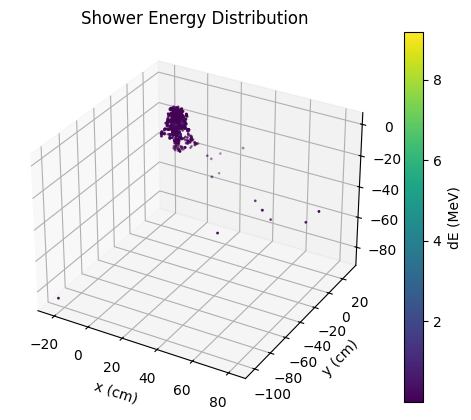

In [5]:
import numpy as np
tree = f.Get("sparse3d_pcluster_tree")
print('Number of entries', tree.GetEntries())
total_event_value_sum = []
pos_x_start = []
pos_y_start = []
pos_z_start = []


for entry in range(tree.GetEntries()):
    if entry != 26:
        continue
    tree.GetEntry(entry)
    print("Entry:", tree.GetEntry(entry))
    event = tree.sparse3d_pcluster_branch
    #print("Event:", event)
    #print("Event Meta:", event.meta())
    event_meta = event.meta()
    #print("Event meta().dump():", event.meta().dump())
    sparse3d = event.as_vector()
    #print("Sparse3D:", sparse3d)
    print("Number of sparse3d = ", len(sparse3d))
    sparse3d_ids = []
    sparse3d_values = []
    idx = 0
    for s in sparse3d:
        sid = s.id()
        position_x = event_meta.pos_x(sid)
        position_y = event_meta.pos_y(sid)
        position_z = event_meta.pos_z(sid)
        pos_x_start.append(position_x)
        pos_y_start.append(position_y)
        pos_z_start.append(position_z)
        #print("Position:", position_x, position_y, position_z)
        sparse3d_values.append(s.value())
        idx += 1
        #print("Value:", s.value())
        #break
    #print(np.array(sparse3d_ids))
    total_event_value_sum.append(np.sum(np.array(sparse3d_values)))

print("Total event value sums:", np.array(total_event_value_sum))
print("Position x start:", pos_x_start)
print("Position y start:", pos_y_start)
print("Position z start:", pos_z_start) 
pos_x_start = np.array(pos_x_start)
pos_y_start = np.array(pos_y_start) 
pos_z_start = np.array(pos_z_start)

import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

shower = ax.scatter(pos_x_start/10,pos_y_start/10, pos_z_start/10, c=sparse3d_values, cmap='viridis', s=1)
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_zlabel('z (cm)')
ax.set_title('Shower Energy Distribution')
plt.colorbar(shower, ax=ax, label='dE (MeV)')
plt.show()

In [6]:
# Check against original edep-sim hdf5 file: 
import h5py 
# Get shower data function 
def get_shower_data(sim_h5, event_id):

    parse_var='event_id'
    seg_var='segments'     

    traj_spill_mask = sim_h5['trajectories'][:][parse_var]==event_id
    seg_spill_mask = sim_h5[seg_var][:][parse_var]==event_id
    event_mask = sim_h5['events'][:][parse_var]==event_id

    traj = sim_h5['trajectories'][traj_spill_mask]
    seg = sim_h5[seg_var][seg_spill_mask]
    event = sim_h5['events'][event_mask]

    return traj, seg, event

In [7]:
edep_sim_file = "/pscratch/sd/e/ehinkle/nd_ana/sheep_single_shower/NDLAR_ELECTRON_SAMPLES/CONVERT2H5/electron_NDLAr_10MeVto15GeV_TEST5.1002.CONVERT2H5.hdf5"
#edep_sim_file = "/pscratch/sd/e/ehinkle/nd_ana/sheep_single_shower/ELECTRON_SAMPLES/CONVERT2H5/TEST/electron_positron_10MeVto2GeV.8947.CONVERT2H5.hdf5"
sim_h5 = h5py.File(edep_sim_file, 'r')
event_energy = []
total_seg_energy = []

num_events = len(np.unique(sim_h5['events']['event_id']))
for event_id in range(num_events):
    traj, seg, events = get_shower_data(sim_h5, event_id)
    event_energy.append(events['E_start'][0])
    total_seg_energy.append(np.sum(seg['dE']))


event_energy = np.array(event_energy)
total_seg_energy = np.array(total_seg_energy)
print("Total segment energy:", total_seg_energy)

Total segment energy: [ 2974.0754  9772.039   5117.545  13075.184   5087.075  12487.97
 12355.044   5735.5376  5517.637   4814.91    1107.636  13816.11
 13702.016  11897.436   8297.166   9152.552   4826.8315  2285.1572
  8520.874   8719.386   4142.524   5349.11    6489.6333 10367.708
  9103.277   7730.385   2709.5154  6558.455   7991.7515   647.2311
 10371.319   9908.44   11317.069   7671.7246 12633.913   3492.522
  8767.906   4250.186  13312.326  13037.765   1387.4425  3234.0547
  1900.3887  3680.025  10634.664   2998.9097  3603.2754  1746.5479
  2953.891  11483.002 ]


In [8]:
total_event_value_sum = np.array(total_event_value_sum)

diff_event_val_sum_total_seg_energy = total_event_value_sum - total_seg_energy
diff_energy_init_values_event_energy = energy_init_values - event_energy
#print("Event energy:", event_energy)
#print("Energy init values:", energy_init_values)
print("Difference between total event value sum and total segment energy:", diff_event_val_sum_total_seg_energy)
print("Difference between energy init LARCV and event energy edep-sim:", diff_energy_init_values_event_energy)

Difference between total event value sum and total segment energy: [-2.64560030e+02 -7.06252365e+03 -2.40802951e+03 -1.03656682e+04
 -2.37755979e+03 -9.77845432e+03 -9.64552854e+03 -3.02602219e+03
 -2.80812180e+03 -2.10539475e+03  1.60187942e+03 -1.11065949e+04
 -1.09925002e+04 -9.18792014e+03 -5.58765061e+03 -6.44303635e+03
 -2.11731613e+03  4.24358183e+02 -5.81135861e+03 -6.00987033e+03
 -1.43300852e+03 -2.63959445e+03 -3.78011789e+03 -7.65819260e+03
 -6.39376193e+03 -5.02086936e+03  2.85713368e-05 -3.84893967e+03
 -5.28223606e+03  2.06228433e+03 -7.66180393e+03 -7.19892502e+03
 -8.60755393e+03 -4.96220920e+03 -9.92439768e+03 -7.83006563e+02
 -6.05839084e+03 -1.54067063e+03 -1.06028108e+04 -1.03282492e+04
  1.32207290e+03 -5.24539278e+02  8.09126738e+02 -9.70509493e+02
 -7.92514865e+03 -2.89394259e+02 -8.93759981e+02  9.62967558e+02
 -2.44375704e+02 -8.77348654e+03]
Difference between energy init LARCV and event energy edep-sim: [-4.69315419e-05 -4.24032365e-04 -1.72599337e-04 -1.679

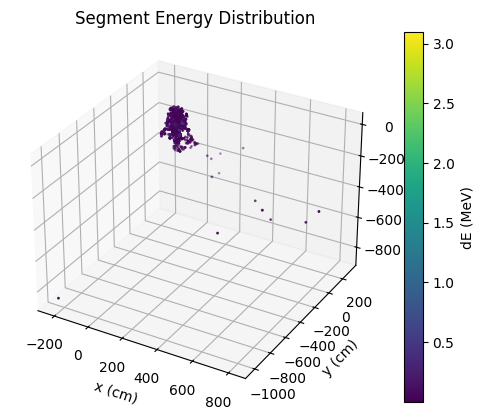

In [9]:
traj, seg, events = get_shower_data(sim_h5, 26)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

shower = ax.scatter(seg['x'], seg['y'], seg['z'], c=seg['dE'], cmap='viridis', s=1)
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_zlabel('z (cm)')
ax.set_title('Segment Energy Distribution')
plt.colorbar(shower, ax=ax, label='dE (MeV)')
plt.show()

In [51]:
# Access LARCV file with parser
DATA_PATH = fname

cfg = """
base:
  verbosity: info
io:
  loader:
    batch_size: 50
    shuffle: False
    num_workers: 4
    collate_fn: all
    dataset:
      name: larcv
      file_keys: DATA_PATH
      limit_num_files: 10
      #entry_list: [6436, 562, 3802, 6175, 15256] # can also be specified as a file
      #skip_entry_list: [12, 354] # can also be specified as a file
      schema:
        input_data:
          parser: sparse3d
          sparse_event: sparse3d_pcluster
        particles:
          parser: particle
          particle_event: particle_pcluster
          sparse_event: sparse3d_pcluster
        meta:
          parser: meta
          sparse_event: sparse3d_pcluster
""".replace('DATA_PATH', DATA_PATH)

print(cfg)


base:
  verbosity: info
io:
  loader:
    batch_size: 50
    shuffle: False
    num_workers: 4
    collate_fn: all
    dataset:
      name: larcv
      file_keys: /global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/electron_NDLAr_10MeVto15GeV_TEST5.1002.LARCV.root
      limit_num_files: 10
      #entry_list: [6436, 562, 3802, 6175, 15256] # can also be specified as a file
      #skip_entry_list: [12, 354] # can also be specified as a file
      schema:
        input_data:
          parser: sparse3d
          sparse_event: sparse3d_pcluster
        particles:
          parser: particle
          particle_event: particle_pcluster
          sparse_event: sparse3d_pcluster
        meta:
          parser: meta
          sparse_event: sparse3d_pcluster



In [52]:
import yaml
import sys 
sys.path.append("/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/spine")
import spine
from spine.driver import Driver

cfg = yaml.safe_load(cfg)



In [53]:
driver = Driver(cfg)
data = driver.process()


 ██████████   ██████████    ███   ███       ██   ███████████
███        █  ██       ███   █    █████     ██   ██         
  ████████    ██       ███  ███   ██  ████  ██   ██████████ 
█        ███  ██████████     █    ██     █████   ██         
 ██████████   ██            ███   ██       ███   ███████████

Release version: 0.10.3

$CUDA_VISIBLE_DEVICES=None

Configuration processed at: Linux login11 6.4.0-150600.23.73_15.0.14-cray_shasta_c #1 SMP Tue Oct 21 20:32:25 UTC 2025 (89d3c98) x86_64 x86_64 x86_64 GNU/Linux

base: {verbosity: info, world_size: 0, seed: 1776702931}
io:
  loader:
    batch_size: 50
    shuffle: false
    num_workers: 4
    collate_fn: all
    dataset:
      name: larcv
      file_keys: /global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/electron_NDLAr_10MeVto15GeV_TEST5.1002.LARCV.root
      limit_num_files: 10
      schema:
        input_data: {parser: sparse3d, sparse_event: sparse3d_pcluster}
        particles: {parser: particle, parti

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fe5743af910>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process


In [54]:
event_id = 26

# Get true energy:
particles = data['particles'][event_id]
true_energy = particles[0].energy_init
print("True energy:", true_energy)

# Get positions and energies for each filled voxel:
positions = data['input_data'][event_id][:,1:4]
energy_per_voxel = data['input_data'][event_id][:,4]
input_data_full = data['input_data'][event_id]

print("Input data:", input_data_full)
print("Positions (voxel):", positions)
print("Energy per voxel:", energy_per_voxel)

# Get positions for each filled voxel (actual x, y, z coordinates):
meta = data['meta'][event_id]
positions_cm = meta.to_cm(positions, center=True)
print("Positions (cm):", positions_cm)

True energy: 2738.1190841596353
Input data: [[2.6000000e+01 1.2839000e+04 1.0697000e+04 1.1131000e+04 3.6161384e-03]
 [2.6000000e+01 1.4868000e+04 1.3560000e+04 1.1890000e+04 1.1603719e-03]
 [2.6000000e+01 1.4488000e+04 1.2531000e+04 1.1988000e+04 3.3373988e-05]
 ...
 [2.6000000e+01 1.3388000e+04 1.3423000e+04 1.3456000e+04 3.2433633e-02]
 [2.6000000e+01 1.3451000e+04 1.3450000e+04 1.3465000e+04 1.7136508e-01]
 [2.6000000e+01 1.3403000e+04 1.3410000e+04 1.3467000e+04 7.2501922e-01]]
Positions (voxel): [[12839. 10697. 11131.]
 [14868. 13560. 11890.]
 [14488. 12531. 11988.]
 ...
 [13388. 13423. 13456.]
 [13451. 13450. 13465.]
 [13403. 13410. 13467.]]
Energy per voxel: [3.6161384e-03 1.1603719e-03 3.3373988e-05 ... 3.2433633e-02 1.7136508e-01
 7.2501922e-01]
Positions (cm): [[ -223.57812   -1020.42334    -858.9712   ]
 [  531.23         44.641113   -576.6157   ]
 [  389.8662     -338.15723    -540.1587   ]
 ...
 [  -19.344727     -6.3242188     5.9521484]
 [    4.091797      3.7202148    

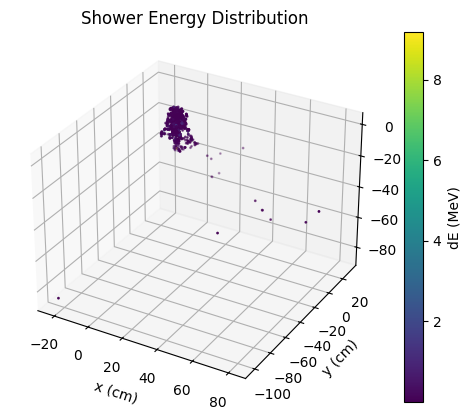

In [55]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

shower = ax.scatter(positions_cm[:,0]/10,positions_cm[:,1]/10,positions_cm[:,2]/10, c=energy_per_voxel, cmap='viridis', s=1)
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_zlabel('z (cm)')
ax.set_title('Shower Energy Distribution')
plt.colorbar(shower, ax=ax, label='dE (MeV)')
plt.show()